In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

# !pip install torchvision
import torchvision

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

# !pip install torchmetrics
import torchmetrics


In [3]:
from collections import Counter
images = np.load('images.npy')  # (4750, 128, 128, 3)
labels = pd.read_csv('labels.csv')  # (4750, 1)




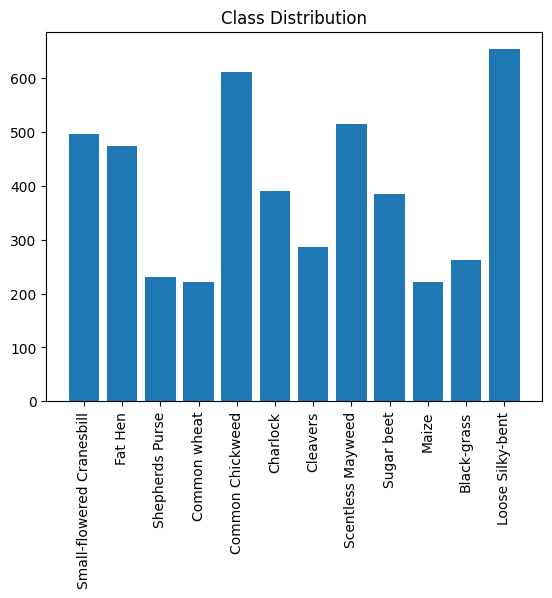

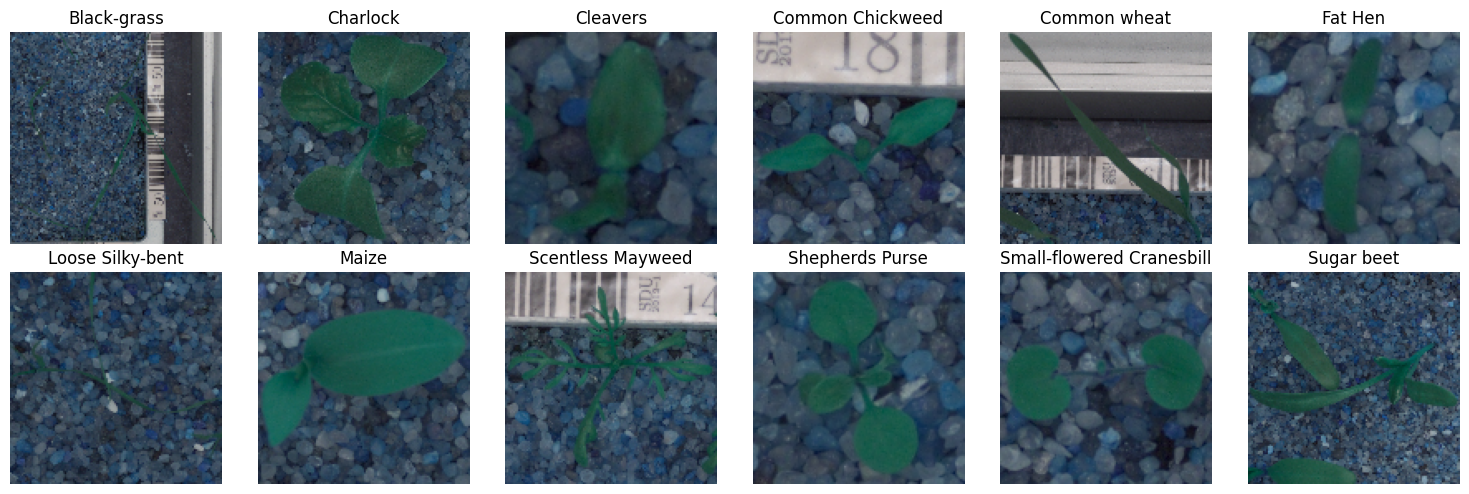

In [61]:
# Class distribution
class_counts = Counter(labels['Label'])  # or whatever column name
plt.bar(class_counts.keys(), class_counts.values())
plt.title('Class Distribution'); plt.xticks(rotation=90)
plt.savefig('class_dist.png')  # Screenshot 1 [file:100]

# Sample images
fig, axes = plt.subplots(2, 6, figsize=(15,5))
classes = sorted(class_counts.keys())[:12]
for i, cls in enumerate(classes):
    row = i // 6
    col = i % 6
    idx = np.where(labels['Label'] == cls)[0][0]
    axes[row,col].imshow(images[idx])
    axes[row,col].set_title(cls)
    axes[row, col].axis("off")
plt.savefig('samples.png')  # Screenshot 2
plt.tight_layout()

print(images.shape)
print(labels.head())

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(labels["Label"])
print(y[:10])
print(le.classes_)  # to see the mapping


[10 10 10 10 10 10 10 10 10 10]
['Black-grass' 'Charlock' 'Cleavers' 'Common Chickweed' 'Common wheat'
 'Fat Hen' 'Loose Silky-bent' 'Maize' 'Scentless Mayweed'
 'Shepherds Purse' 'Small-flowered Cranesbill' 'Sugar beet']


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    images, y, test_size=0.4, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(len(X_train), len(X_val), len(X_test))


2850 950 950


In [6]:
import numpy as np

np.save("X_train.npy", X_train)
np.save("y_train.npy", y_train)
np.save("X_val.npy",   X_val)
np.save("y_val.npy",   y_val)
np.save("X_test.npy",  X_test)
np.save("y_test.npy",  y_test)


In [135]:
print("X_train type/shape:", type(X_train), getattr(X_train, "shape", None))
print("y_train type/shape:", type(y_train), getattr(y_train, "shape", None))
print("len(X_train):", len(X_train))


X_train type/shape: <class 'numpy.ndarray'> (2850, 128, 128, 3)
y_train type/shape: <class 'numpy.ndarray'> (2850,)
len(X_train): 2850


In [4]:
from torch.utils.data import Dataset

class SeedlingDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X              # NumPy: (N, 128, 128, 3), uint8
        self.y = y              # 1D NumPy: encoded labels
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx]                     # (H, W, C)
        label = self.y[idx]

        img = img / 255.0                     # [0,1]
        img = torch.tensor(img, dtype=torch.float32)
        img = img.permute(2, 0, 1)            # (C, H, W) for PyTorch

        if self.transform:
            img = self.transform(img)         # transforms on tensor

        label = torch.tensor(label, dtype=torch.long)
        return img, label

In [8]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(45),
    transforms.Resize((64,64)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],             
        std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([transforms.Resize((64,64)), 
            transforms.Normalize(mean=[0.485, 0.456, 0.406],             
        std=[0.229, 0.224, 0.225])
])
train_ds = SeedlingDataset(X_train, y_train, transform=train_transform)
val_ds   = SeedlingDataset(X_val,   y_val, transform=val_transforms)  # no augmentation

In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=10, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=10, shuffle=False)


In [10]:
images_batch, labels_batch = next(iter(train_loader))
print(images_batch.shape, labels_batch.shape)


torch.Size([10, 3, 64, 64]) torch.Size([10])




fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    img, label = train_ds[i]              # already augmented + normalized
    img_np = img.permute(1, 2, 0).numpy() # (H, W, C)
    axes[i].imshow(img_np)  
    axes[i].axis("off")
plt.tight_layout()



In [11]:

import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Flatten(),
            
        )
       
           
        self.classifier = nn.Linear(8192, num_classes)

    def forward(self, x):
        x = self.feature_extractor(x)  

        x = self.classifier(x)
        return x


In [12]:
for i, (X_train, y_train) in enumerate(train_ds):
    break


In [142]:
X_train.shape

torch.Size([3, 64, 64])

import time

net = Net(num_classes=12)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.001)

for epoch in range(3):
    start = time.time()
    running_loss = 0.0
    for i, (images, labels) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        if (i + 1) % 10 == 0:
            print(f"Epoch {epoch+1}, batch {i+1}, loss {running_loss / 10:.4f}")
            running_loss = 0.0

    print(f"Epoch {epoch+1} finished in {time.time() - start:.1f} sec")




In [ ]:
import torch

# choose a filename
model_path = "cnn_model.pth"

torch.save(net.state_dict(), model_path)
print("Model saved to", model_path)


In [13]:
net = Net(num_classes=12)
net.load_state_dict(torch.load('cnn_model.pth'))

<All keys matched successfully>

In [144]:
net.eval()  # evaluation mode (turns off dropout, etc.)

images, labels = next(iter(val_loader))  # or val_loader, or train_loader
with torch.no_grad():                     # no gradients needed
    outputs = net(images)                 # shape: [batch_size, num_classes]


In [145]:
_, preds = torch.max(outputs, dim=1)  # shape: [batch_size]


for i in range(10):
    print(f"Predicted: {le.classes_[preds[i]]}, Actual: {le.classes_[labels[i]]}")


Predicted: Scentless Mayweed, Actual: Common Chickweed
Predicted: Scentless Mayweed, Actual: Common Chickweed
Predicted: Loose Silky-bent, Actual: Loose Silky-bent
Predicted: Small-flowered Cranesbill, Actual: Small-flowered Cranesbill
Predicted: Charlock, Actual: Maize
Predicted: Black-grass, Actual: Loose Silky-bent
Predicted: Scentless Mayweed, Actual: Common Chickweed
Predicted: Small-flowered Cranesbill, Actual: Small-flowered Cranesbill
Predicted: Scentless Mayweed, Actual: Common Chickweed
Predicted: Scentless Mayweed, Actual: Common Chickweed


In [146]:
print(type(y_train), getattr(y_train, "shape", None))
print(len(X_train))


<class 'torch.Tensor'> torch.Size([])
3


In [17]:
from torchmetrics import Accuracy
from tqdm.auto import tqdm 

num_classes = 12
def compute_accuracy(loader, model):
    metric = Accuracy(task="multiclass", num_classes=num_classes)
    model.eval()
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", total=len(loader)):
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            metric.update(preds, labels)
    return metric.compute()


#train_acc = compute_accuracy(train_loader, net)
val_acc   = compute_accuracy(val_loader, net)

#print(f"Training accuracy:   {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")


/opt/miniconda3/envs/pytorchcpu/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Evaluating: 100%|██████████| 95/95 [00:45<00:00,  2.08it/s]

Validation accuracy: 0.4779


In [14]:

import random
import math

num_classes = 12

def compute_accuracy(loader, model):
    metric = Accuracy(task="multiclass", num_classes=num_classes)
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            preds = outputs.argmax(dim=1)
            metric.update(preds, labels)
    return metric.compute().item()

def train_with_hparams(lr, momentum, num_epochs=3):
    print(f"\n=== lr={lr:.5f}, momentum={momentum:.2f} ===")
    model = Net(num_classes=num_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, momentum=momentum)

    for epoch in range(num_epochs):
        model.train()
        for images, labels in train_loader:   # TRAIN set only
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    train_acc = compute_accuracy(train_loader, model)
    val_acc   = compute_accuracy(val_loader,   model)
    print(f"train_acc={train_acc:.3f}, val_acc={val_acc:.3f}")
    return model, train_acc, val_acc



In [157]:
import torch
import torch.nn as nn

search_space = [
    {"opt": "adam", "lr": 1e-4, "wd": 0.0},
    {"opt": "adam", "lr": 3e-4, "wd": 0.0},
    {"opt": "adam", "lr": 1e-3, "wd": 0.0},
    {"opt": "adam", "lr": 3e-4, "wd": 1e-4},
    {"opt": "sgd",  "lr": 1e-3, "wd": 0.0},
    {"opt": "sgd",  "lr": 3e-3, "wd": 1e-4},
    
]

def make_optimizer(model, config):
    if config["opt"] == "adam":
        return torch.optim.Adam(model.parameters(),
                                lr=config["lr"],
                                weight_decay=config["wd"])
    else:  # sgd
        return torch.optim.SGD(model.parameters(),
                               lr=config["lr"],
                               momentum=0.9,
                               weight_decay=config["wd"])

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)

def evaluate_acc(loader, model):
    return compute_accuracy(loader, model)   # your existing function


In [159]:
import torch
import torch.nn as nn

num_classes = 12
criterion = nn.CrossEntropyLoss()

search_space = [
    {"opt": "adam", "lr": 1e-4, "wd": 0.0},
    {"opt": "adam", "lr": 3e-4, "wd": 0.0},
    {"opt": "adam", "lr": 1e-3, "wd": 0.0},
    {"opt": "adam", "lr": 3e-4, "wd": 1e-4},
    {"opt": "sgd",  "lr": 1e-3, "wd": 0.0},
    {"opt": "sgd",  "lr": 3e-3, "wd": 1e-4},
]

def make_optimizer(model, config):
    if config["opt"] == "adam":
        return torch.optim.Adam(model.parameters(),
                                lr=config["lr"],
                                weight_decay=config["wd"])
    else:
        return torch.optim.SGD(model.parameters(),
                               lr=config["lr"],
                               momentum=0.9,
                               weight_decay=config["wd"])

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    return running_loss / len(loader.dataset)

def evaluate_acc(loader, model):
    return compute_accuracy(loader, model)  # your torchmetrics-based fn

results = []

for cfg_idx, config in enumerate(search_space, start=1):
    print(f"\n=== Config {cfg_idx}/{len(search_space)}: "
          f"opt={config['opt']}, lr={config['lr']}, wd={config['wd']} ===")

    model = Net(num_classes=num_classes)
    optimizer = make_optimizer(model, config)

    best_val_acc_for_cfg = 0.0
    for epoch in range(3):  # short run per config
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc    = evaluate_acc(val_loader, model)

        print(f"  epoch {epoch+1}/3 | "
              f"train_loss={train_loss:.4f} | val_acc={val_acc:.4f}")

        if val_acc > best_val_acc_for_cfg:
            best_val_acc_for_cfg = val_acc

    print(f"--> Best val_acc for this config: {best_val_acc_for_cfg:.4f}")
    results.append((config, best_val_acc_for_cfg))

print("\n=== Grid search summary ===")
for config, acc in results:
    print(f"opt={config['opt']}, lr={config['lr']}, wd={config['wd']} "
          f"=> best_val_acc={acc:.4f}")

best_config, best_acc = max(results, key=lambda x: x[1])
print(f"\nChosen config: {best_config} with val_acc={best_acc:.4f}")



=== Config 1/6: opt=adam, lr=0.0001, wd=0.0 ===
  epoch 1/3 | train_loss=2.3630 | val_acc=0.2663
  epoch 2/3 | train_loss=2.1273 | val_acc=0.3421
  epoch 3/3 | train_loss=1.8673 | val_acc=0.4042
--> Best val_acc for this config: 0.4042

=== Config 2/6: opt=adam, lr=0.0003, wd=0.0 ===
  epoch 1/3 | train_loss=2.1452 | val_acc=0.4621
  epoch 2/3 | train_loss=1.4766 | val_acc=0.5263
  epoch 3/3 | train_loss=1.2793 | val_acc=0.6042
--> Best val_acc for this config: 0.6042

=== Config 3/6: opt=adam, lr=0.001, wd=0.0 ===
  epoch 1/3 | train_loss=2.0396 | val_acc=0.4758
  epoch 2/3 | train_loss=1.3875 | val_acc=0.5863
  epoch 3/3 | train_loss=1.2533 | val_acc=0.5863
--> Best val_acc for this config: 0.5863

=== Config 4/6: opt=adam, lr=0.0003, wd=0.0001 ===
  epoch 1/3 | train_loss=2.3496 | val_acc=0.2926
  epoch 2/3 | train_loss=1.7363 | val_acc=0.4768
  epoch 3/3 | train_loss=1.3631 | val_acc=0.5895
--> Best val_acc for this config: 0.5895

=== Config 5/6: opt=sgd, lr=0.001, wd=0.0 ===
  e

net = Net(num_classes=12)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.00062, momentum=0.85)

num_epochs = 10
num_batches = len(train_loader)

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0

    print(f"\nEpoch {epoch+1}/{num_epochs} - {num_batches} batches")

    for batch_idx, (images, labels) in enumerate(train_loader, start=1):
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # progress update every 10 batches (and on the last batch)
        if batch_idx % 10 == 0 or batch_idx == num_batches:
            avg_loss = running_loss / 10 if batch_idx % 10 == 0 else running_loss / (batch_idx % 10)
            print(f"  Batch {batch_idx}/{num_batches}  avg_loss={avg_loss:.4f}")
            running_loss = 0.0



In [ ]:

import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = Net(num_classes=12).to(device)


num_classes = 12
net = Net(num_classes=num_classes)  # fresh model for final run

optimizer = torch.optim.Adam(net.parameters(), lr=3e-4, weight_decay=0.0)
criterion = nn.CrossEntropyLoss()

num_epochs = 20           # max epochs
patience   = 3            # early stopping patience

best_val_acc  = 0.0
epochs_no_improve = 0
best_state_dict = None

train_hist, val_hist = [], []

for epoch in range(num_epochs):
    # ---- training ----
    net.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * labels.size(0)
    train_loss = running_loss / len(train_loader.dataset)

    # ---- validation ----
    val_acc = compute_accuracy(val_loader, net)  # your torchmetrics-based fn
    train_hist.append(train_loss)
    val_hist.append(val_acc.item() if hasattr(val_acc, "item") else float(val_acc))

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"train_loss={train_loss:.4f} | val_acc={val_acc:.4f}")

    # ---- early stopping on validation accuracy ----
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state_dict = net.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# restore best weights
if best_state_dict is not None:
    net.load_state_dict(best_state_dict)


Evaluating: 100%|██████████| 95/95 [00:47<00:00,  2.01it/s]


Epoch 1/20 | train_loss=2.1173 | val_acc=0.4063


Evaluating: 100%|██████████| 95/95 [00:38<00:00,  2.45it/s]


Epoch 2/20 | train_loss=1.5144 | val_acc=0.5495


Evaluating: 100%|██████████| 95/95 [00:41<00:00,  2.32it/s]


...

Epoch 10/20 | train_loss=0.8866 | val_acc=0.7095


Evaluating: 100%|██████████| 95/95 [00:36<00:00,  2.57it/s]


Epoch 11/20 | train_loss=0.8430 | val_acc=0.7000


Evaluating: 100%|██████████| 95/95 [00:36<00:00,  2.62it/s]

Epoch 12/20 | train_loss=0.8055 | val_acc=0.6884
Early stopping at epoch 12


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs validation loss")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
net = Net(num_classes=num_classes)
net.load_state_dict(best_state_dict)

<All keys matched successfully>

In [44]:
model_path = "best_cnn_model.pth"
torch.save(net.state_dict(best_state_dict), model_path)

/opt/miniconda3/envs/pytorchcpu/lib/python3.11/site-packages/torch/nn/modules/module.py:1877: UserWarning: Positional args are being deprecated, use kwargs instead. Refer to https://pytorch.org/docs/master/generated/torch.nn.Module.html#torch.nn.Module.state_dict for details.
  warnings.warn(


In [45]:
net.load_state_dict(best_state_dict)

<All keys matched successfully>

In [46]:
test_ds  = SeedlingDataset(X_test, y_test, transform=val_transforms)
test_loader = DataLoader(test_ds, batch_size=10, shuffle=False)

In [47]:
import torch
from sklearn.metrics import confusion_matrix
import numpy as np

net.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:      
        outputs = net(images)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
cm = confusion_matrix(all_labels, all_preds)  # shape: [num_classes, num_classes]
print(cm)


[[ 11   0   0   0   0   1  39   0   1   0   0   1]
 [  0  57   0   0   0   1   0   3  11   3   2   1]
 [  1   6  34   0   2   0   0   0  11   0   3   0]
 [  0   1   0  84   0   1   1   5  19   4   0   7]
 [  5   0   0   0  13   1  19   0   5   0   0   2]
 [  1   0   0   1   0  57  14   1  12   0   1   8]
 [  6   0   0   1   2   1 118   0   1   0   1   1]
 [  0   0   0   1   0   1   0  35   6   0   0   1]
 [  0   1   0   0   0   0   2   2  93   1   1   3]
 [  0   2   1   5   0   1   0   1  15  19   2   0]
 [  0   1   0   2   0   1   1   1   3   3  83   4]
 [  0   0   0   2   0   2   1   2  18   0   3  49]]


In [48]:
from sklearn.metrics import classification_report

# y_test_enc: encoded test labels (ints)
# y_pred_enc: encoded model predictions (ints)

# 1) Convert back to names
y_test_names = le.inverse_transform(y_test)
y_pred_names = le.inverse_transform(all_preds)

# 2) Per-class performance (precision/recall/F1)
print(classification_report(y_test_names, y_pred_names))


                           precision    recall  f1-score   support

              Black-grass       0.46      0.21      0.29        53
                 Charlock       0.84      0.73      0.78        78
                 Cleavers       0.97      0.60      0.74        57
         Common Chickweed       0.88      0.69      0.77       122
             Common wheat       0.76      0.29      0.42        45
                  Fat Hen       0.85      0.60      0.70        95
         Loose Silky-bent       0.61      0.90      0.72       131
                    Maize       0.70      0.80      0.74        44
        Scentless Mayweed       0.48      0.90      0.62       103
          Shepherds Purse       0.63      0.41      0.50        46
Small-flowered Cranesbill       0.86      0.84      0.85        99
               Sugar beet       0.64      0.64      0.64        77

                 accuracy                           0.69       950
                macro avg       0.72      0.63      0.65    

In [49]:
cm = confusion_matrix(y_test_names, y_pred_names)  # shape: [num_classes, num_classes]
print(cm)

[[ 11   0   0   0   0   1  39   0   1   0   0   1]
 [  0  57   0   0   0   1   0   3  11   3   2   1]
 [  1   6  34   0   2   0   0   0  11   0   3   0]
 [  0   1   0  84   0   1   1   5  19   4   0   7]
 [  5   0   0   0  13   1  19   0   5   0   0   2]
 [  1   0   0   1   0  57  14   1  12   0   1   8]
 [  6   0   0   1   2   1 118   0   1   0   1   1]
 [  0   0   0   1   0   1   0  35   6   0   0   1]
 [  0   1   0   0   0   0   2   2  93   1   1   3]
 [  0   2   1   5   0   1   0   1  15  19   2   0]
 [  0   1   0   2   0   1   1   1   3   3  83   4]
 [  0   0   0   2   0   2   1   2  18   0   3  49]]


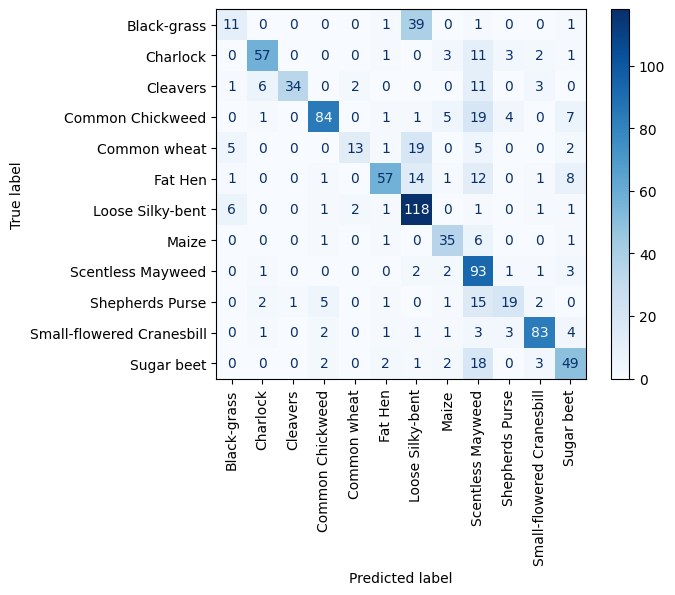

In [52]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le.classes_)
disp.plot(cmap="Blues", xticks_rotation="vertical")
plt.show()


In [50]:
print(net)  # this is your model summary
print("Total trainable parameters:",
      sum(p.numel() for p in net.parameters() if p.requires_grad))


Net(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Linear(in_features=8192, out_features=12, bias=True)
)
Total trainable parameters: 103404


In [54]:
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = Net(num_classes=12).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=3e-4)

# ---------- 3. Training loop with tracking & early stopping ----------
num_epochs = 20
patience = 3

train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs_no_improve = 0
best_state_dict = None

for epoch in range(num_epochs):
    start_time = time.time()

    # ----- train -----
    net.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # progress update every 10 batches
        if (i + 1) % 10 == 0:
            avg_batch_loss = running_loss / 10
            print(f"Epoch {epoch+1}/{num_epochs} "
                  f"| batch {i+1}/{len(train_loader)} "
                  f"| batch_loss={avg_batch_loss:.4f}")
            running_loss = 0.0

    # average train loss for this epoch
    epoch_train_loss = 0.0
    net.eval()
    with torch.no_grad():
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            epoch_train_loss += loss.item()
    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)

    # ----- validation -----
    epoch_val_loss = 0.0
    correct = 0
    total = 0
    net.eval()
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = net(images)
            loss = criterion(outputs, labels)
            epoch_val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)
    val_acc = correct / total

    elapsed = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} "
          f"| train_loss={epoch_train_loss:.4f} "
          f"| val_loss={epoch_val_loss:.4f} "
          f"| val_acc={val_acc:.4f} "
          f"| time={elapsed:.1f}s")

    # early stopping on val loss
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_state_dict = net.state_dict()
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# restore best weights
if best_state_dict is not None:
    net.load_state_dict(best_state_dict)




Epoch 1/20 | batch 10/285 | batch_loss=2.5467
Epoch 1/20 | batch 20/285 | batch_loss=2.4484
Epoch 1/20 | batch 30/285 | batch_loss=2.5079
Epoch 1/20 | batch 40/285 | batch_loss=2.4016
Epoch 1/20 | batch 50/285 | batch_loss=2.4585
Epoch 1/20 | batch 60/285 | batch_loss=2.4155
Epoch 1/20 | batch 70/285 | batch_loss=2.4265
Epoch 1/20 | batch 80/285 | batch_loss=2.3667
Epoch 1/20 | batch 90/285 | batch_loss=2.2921
Epoch 1/20 | batch 100/285 | batch_loss=2.4591
Epoch 1/20 | batch 110/285 | batch_loss=2.3595
Epoch 1/20 | batch 120/285 | batch_loss=2.3554
Epoch 1/20 | batch 130/285 | batch_loss=2.3588
Epoch 1/20 | batch 140/285 | batch_loss=2.3670
Epoch 1/20 | batch 150/285 | batch_loss=2.3412
Epoch 1/20 | batch 160/285 | batch_loss=2.2494
Epoch 1/20 | batch 170/285 | batch_loss=2.2548
Epoch 1/20 | batch 180/285 | batch_loss=2.1997
Epoch 1/20 | batch 190/285 | batch_loss=2.2479
Epoch 1/20 | batch 200/285 | batch_loss=2.2387
Epoch 1/20 | batch 210/285 | batch_loss=2.0602
Epoch 1/20 | batch 220

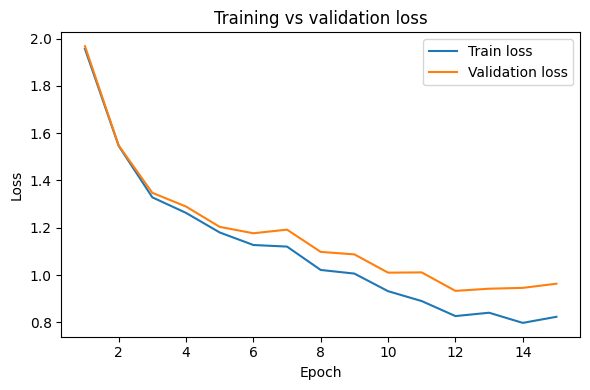

In [55]:
# ---------- 4. Plot train vs validation loss ----------
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(train_losses)+1), train_losses, label="Train loss")
plt.plot(range(1, len(val_losses)+1),   val_losses,   label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs validation loss")
plt.legend()
plt.tight_layout()
plt.show()